Ejercicio: simular y visualizar GPs
El objetivo es aprender a simular trayectorias de un GP, usando algunas de las herramientas más habituales de machine learning (las que hemos visto: Python, Numpy, matplotlib). Como resultado final, generaremos las imágenes vistas en las diapositivas.

Nota: Si escribís sobre este notebook que os comparto, vuestros cambios no se guardarán (porque solo tenéis permisos de lectura). Igual que con el PAS, tendréis que crear una copia vuestra ("Archivo > Guardar una copia en Drive").

In [1]:
# Importamos librerías básicas que utilizaremos

import numpy as np
import matplotlib.pyplot as plt
import math

1. Muestras de una normal multivariante / multidimensional
Puesto que simular trayectorias de un GP involucra simular de una normal multivariante, veamos primero cómo hacer esto.

En la siguiente celda se deben obtener 50 muestras de una normal 3-dimensional $(X_1,X_2,X_3)$ que sigue una distribución normal $\mathcal{N}(0,I_{3\times 3})$

Para ello, utiliza la función `np.random.multivariate_normal` (busca en internet cómo usarla).

Además, visualiza el resultado obtenido, así como su shape.

In [2]:
# COMPLETAR!

vector_medias = np.array([0,0,0])
matriz_covarianzas =  np.diag([1, 1, 1])
num_samples = 50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)


Shape:  (50, 3)
Muestras: 
[[-0.29822327 -1.68482979  0.68453738]
 [-1.18121585 -2.17473492 -0.24006778]
 [-0.20231411 -0.75444624 -0.0940378 ]
 [ 0.57027983 -0.12936647 -1.1694033 ]
 [ 0.11928223 -1.50032417 -1.64533976]
 [-0.34284746  2.358937    1.17366911]
 [-3.68829993  1.23664758  0.62279165]
 [ 0.24885928  0.37862981 -0.54688889]
 [-0.88282854  1.2459907   0.23161453]
 [-0.55384743  0.17305164  1.31315702]
 [ 0.43291534 -1.25844725  0.72610644]
 [ 0.72986696  0.1715746   0.54741322]
 [-0.52574151 -0.21617106 -0.24677787]
 [ 1.12844867 -0.04938979  0.98628438]
 [ 0.10675755 -0.92082026 -0.78838906]
 [-1.01607347 -0.01768684 -1.00356712]
 [ 1.98219134  0.97825083 -0.18830597]
 [-1.47369847 -0.35915384 -1.10335024]
 [ 0.64877852  0.99339043  1.23870327]
 [-0.67931233  0.29754857  0.52630234]
 [-0.47878777  0.74285865 -0.21592531]
 [ 1.01777769 -1.86704882  0.13626399]
 [ 1.03117475 -0.79197988  0.64826464]
 [-0.60126461 -0.42726624 -0.22358648]
 [-0.29083894  1.49837784 -0.15465703

Haz ahora lo mismo pero para una normal con matriz de covarianzas que no sea la identidad, sino por ejemplo $$\Sigma=\begin{pmatrix}1 & 0 & 0 \\
0 & 10 & 0 \\
0 & 0 & 100 \end{pmatrix}$$

Puedes simplificar algo el código si usas la función `np.diag`.

¿Qué diferencias esperarías ver en las muestras obtenidas?

In [3]:
# COMPLETAR!

vector_medias = np.array([0,0,0])
matriz_covarianzas = np.diag([1, 10, 100])
num_samples = 50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas,num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[-5.36100615e-01 -2.26719088e+00 -2.87479418e+00]
 [-1.13602480e+00  4.55791425e-01 -1.42431501e+01]
 [-4.76863626e-01 -3.85972820e+00 -6.76468481e+00]
 [ 1.18822444e+00  4.86666902e+00  8.87826225e+00]
 [ 1.09486168e+00 -2.77571291e+00  3.02667420e+00]
 [-2.55207523e-01  2.45147557e-01  6.63342717e+00]
 [ 3.00662433e-02 -2.94195384e+00 -7.05935841e+00]
 [-3.21173628e-02 -4.34610274e+00  3.31942349e+00]
 [ 1.19631029e+00  3.11457777e+00  4.88721877e+00]
 [-6.18999222e-01 -3.57794220e+00 -8.86486687e+00]
 [-3.82160100e-01 -2.13435569e+00  4.74793158e+00]
 [ 4.34561609e-04 -3.58244303e+00 -1.24700710e+00]
 [ 3.63162995e-01  1.40215368e+00  6.16744042e-01]
 [-2.88495828e-01 -1.43859789e+00 -4.10068017e+00]
 [ 2.02802209e+00 -1.93800100e+00  1.45845494e+01]
 [-4.67334880e-01  3.88671472e+00  5.32926088e+00]
 [-8.95706637e-01  4.43974469e+00 -1.45414527e+00]
 [ 5.14630372e-01  1.91926264e+00 -5.68307348e-01]
 [-1.80772246e-01 -1.82584969e+00 -2.02874258e+01]
 [-8

## 2. Simular un GP con kernel RBF

En esta sección vamos a definir una función `simular_GP_RBF` que nos permita simular de un GP con kernel RBF. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

En el punto 5 se explicará la manera más limpia de usar otras funciones de medias. También se comentará la manera más adecuada para pasar el kernel como argumento de la función. Es decir, de modo que no sea necesario definir `simular_GP_RBF`, sino simplemente `simular_GP` (y que el kernel se pase como argumento de la función). Todo ello necesita del concepto de _clases_, algo que (creo) no se estudia en el grado en matemáticas.

In [4]:
 # COMPLETAR

def simular_GP_RBF(t, sigma_sq=1, lengthscale=1, num_samples=1):
  """
  Simular un GP con kernel RBF.

  Input:
  t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
  sigma_sq: varianza del kernel. Float.
  lengthscale: parámetro de escala del kernel. Float.
  num_samples: número de muestras a generar. Int.

  Output:
  samples: muestras del GP. Numpy array de shape (num_samples, n).

  """

  # Paso 1: calcula el vector de medias. No uses bucles for, puedes usar np.zeros_like
  vector_medias = np.zeros(len(t))

  # Paso 2: calcula la matriz de covarianzas. No uses bucles for, utiliza la vectorización de numpy y en particular la idea de broadcasting que se comentó en la intro a numpy.
  difs = t[:, None] - t[None, :]
  matriz_covs = sigma_sq* np.exp(-0.5*(difs/lengthscale)**2)

  # Paso 3: obtén las muestras/simulaciones del GP. Utiliza la función vista antes: np.random.multivariate_normal
  samples = np.random.multivariate_normal(vector_medias, matriz_covs,num_samples)

  return samples

Ahora utilizamos esta función para generar imágenes similares a las de las diapositivas 59 y 62.

Para ello, genera las trayectorias con la función recién definida, `simular_GP_RBF`, y píntalas con `plt.plot`

Opcional: si quieres tener diferentes ejes (subplots) en la misma figura, como se hace en las diapositivas 59 y 62, puedes mirar cómo usar `plt.subplots`.

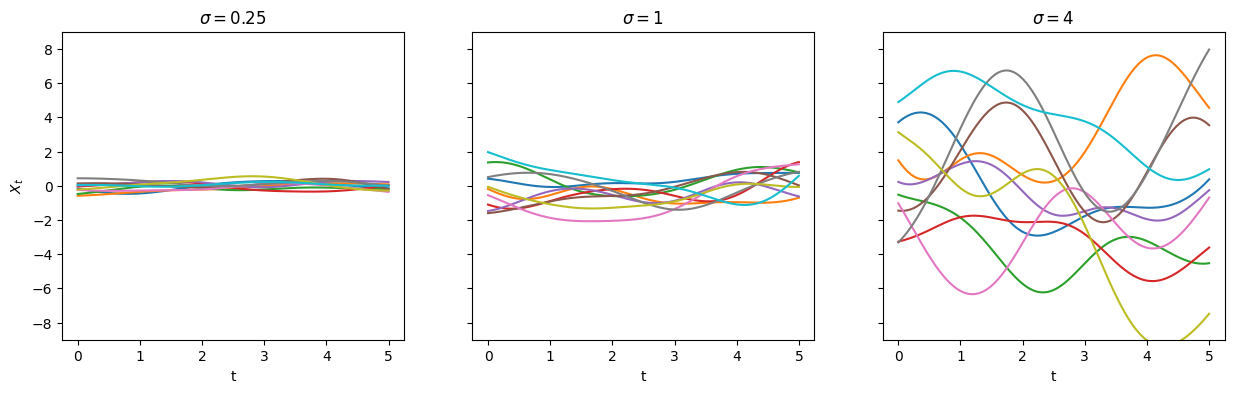

In [5]:
# COMPLETAR (PARA LA DIAPOSITIVA 59)
t = np.linspace(0, 5, 200)
# Parámetros
lengthscale = 1
sigmas = [0.25, 1, 4]
num_samples = 10

# Crear figura con 3 subplots
fig, ejes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True) #esto último para que compartan eje y y se parezca más a las diapos

for i, sigma in enumerate(sigmas):

    # la función recibe sigma_sq, por eso usamos sigma**2
    samples = simular_GP_RBF(
        t,
        sigma_sq=sigma**2,
        lengthscale=lengthscale,
        num_samples=num_samples
    )

    # Pintar trayectorias
    for j in range(num_samples):
        ejes[i].plot(t, samples[j])

    # Títulos y etiquetas
    ejes[i].set_title(rf"$\sigma = {sigma}$")
    ejes[i].set_xlabel("t")


# Etiqueta del eje y solo en el primer subplot
ejes[0].set_ylabel(r"$X_t$")

# Misma escala vertical para los tres gráficos
ejes[0].set_ylim(-9, 9)

plt.show()

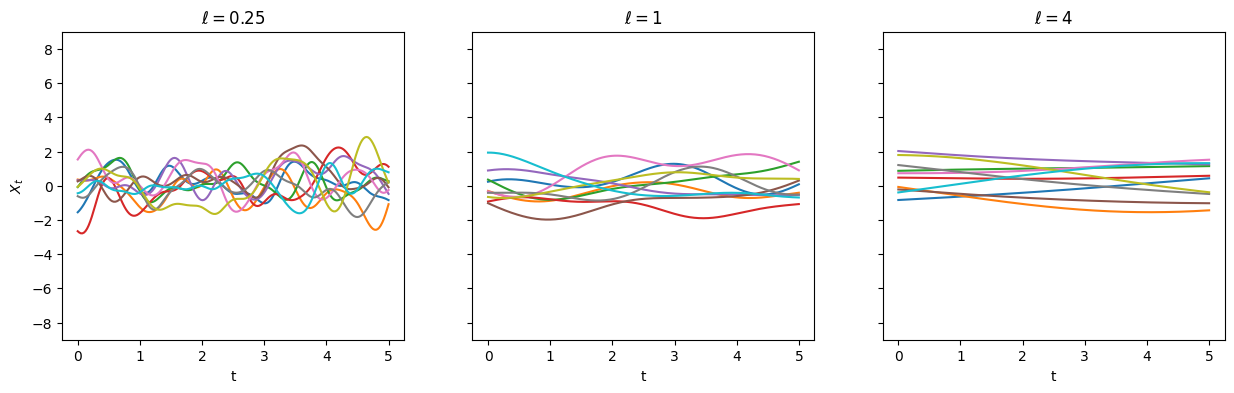

In [6]:
# COMPLETAR (PARA LA DIAPOSITIVA 62)

t = np.linspace(0, 5, 200)
# Parámetros
lengthscale = [0.25,1,4]
sigmas = 1
num_samples = 10

# Crear figura con 3 subplots
fig, ejes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True) #esto último para que compartan eje y y se parezca más a las diapos

for i, l in enumerate(lengthscale):

    # la función recibe sigma_sq, por eso usamos sigma**2
    samples = simular_GP_RBF(
        t,
        sigma_sq=sigmas**2,
        lengthscale=l,
        num_samples=num_samples
    )

    # Pintar trayectorias
    for j in range(num_samples):
        ejes[i].plot(t, samples[j])

    # Títulos y etiquetas
    ejes[i].set_title(rf"$\ell = {l}$")
    ejes[i].set_xlabel("t")


# Etiqueta del eje y solo en el primer subplot
ejes[0].set_ylabel(r"$X_t$")

# Misma escala vertical para los tres gráficos
ejes[0].set_ylim(-9, 9)

plt.show()

3. Simular un GP con kernel periódico


En esta sección vamos a definir una función `simular_GP_periodic` que nos permita simular de un GP con kernel periódico. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.


In [17]:
# COMPLETAR

def simular_GP_periodic(t,sigma,lengthscale,periodo,num_samples):

  # COMPLETAR
  vector_medias = np.zeros(len(t))

  difs = t[:, None] - t[None, :]
  matriz_covs = (sigma**2)* np.exp(((-2/lengthscale**2)*np.sin(np.pi * difs / periodo)**2))

  samples = np.random.multivariate_normal(vector_medias, matriz_covs,num_samples)

  return samples

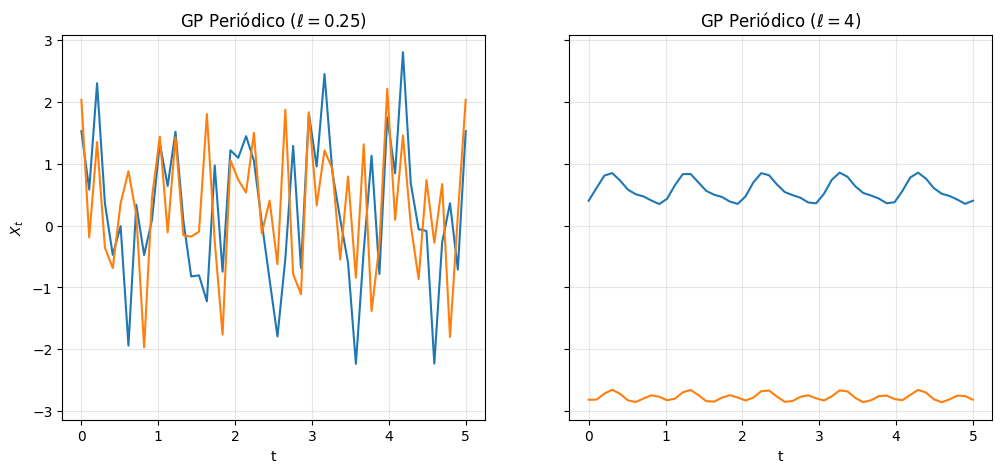

In [20]:
# COMPLETAR (PARA LA DIAPOSITIVA 72)
t = np.linspace(0, 5)
# Parámetros
lengthscale = [0.25,4]
sigma = 1
p = 1
num_samples = 2

fig, ejes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, l in enumerate(lengthscale):

    samples = simular_GP_periodic(
        t,
        sigma=sigma,
        lengthscale=l,
        periodo=p,
        num_samples=num_samples
    )

    # Pintar trayectorias
    for j in range(num_samples):
        ejes[i].plot(t, samples[j])
    ejes[i].set_title(rf"GP Periódico ($\ell = {l}$)")
    ejes[i].set_xlabel("t")
    ejes[i].grid(True, alpha=0.3)

ejes[0].set_ylabel(r"$X_t$")


plt.show()

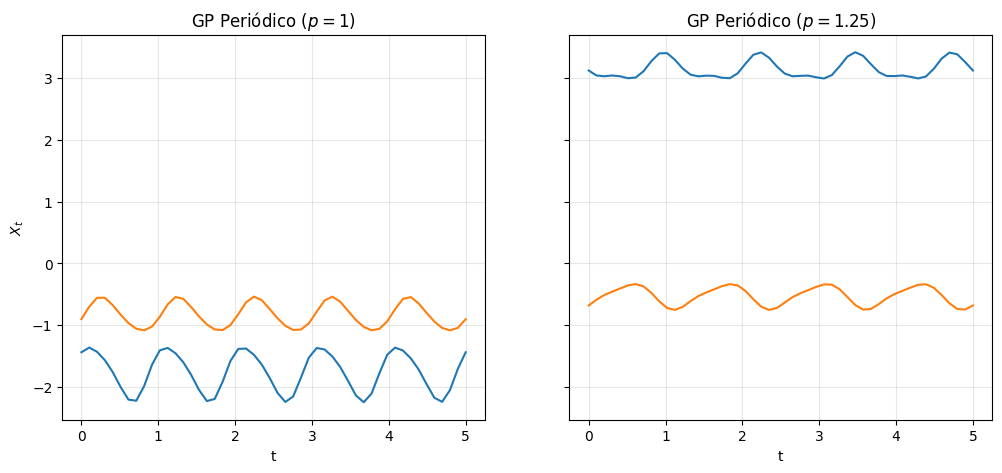

In [24]:
# COMPLETAR (PARA LA DIAPOSITIVA 74)
t = np.linspace(0, 5)
# Parámetros
lengthscale = 1
sigma = 1
p = [1,1.25]
num_samples = 2

fig, ejes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, per in enumerate(p):

    samples = simular_GP_periodic(
        t,
        sigma=sigma,
        lengthscale=l,
        periodo=per,
        num_samples=num_samples
    )

    # Pintar trayectorias
    for j in range(num_samples):
        ejes[i].plot(t, samples[j])
    ejes[i].set_title(rf"GP Periódico ($p = {per}$)")
    ejes[i].set_xlabel("t")
    ejes[i].grid(True, alpha=0.3)

ejes[0].set_ylabel(r"$X_t$")


plt.show()

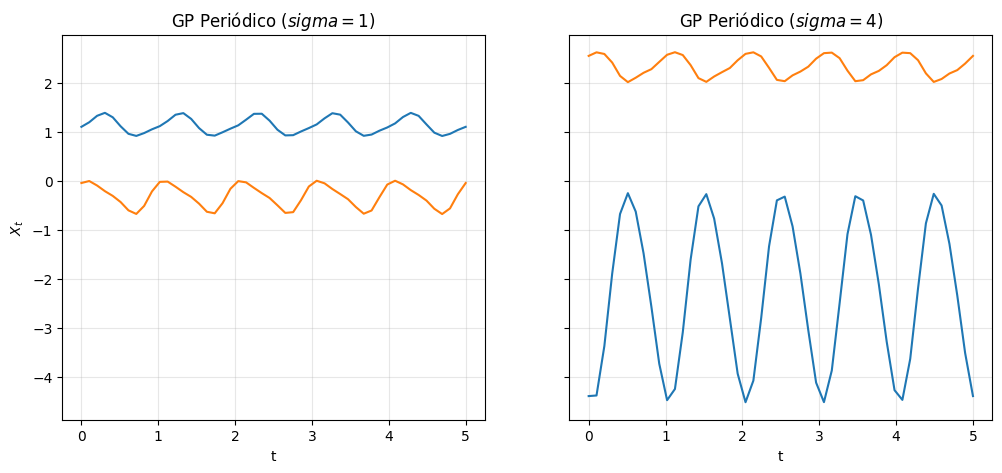

In [26]:
# COMPLETAR (PARA LA DIAPOSITIVA 76)
t = np.linspace(0, 5)
# Parámetros
lengthscale = 1
sigma = [1,4]
p = 1
num_samples = 2

fig, ejes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, s in enumerate(sigma):

    samples = simular_GP_periodic(
        t,
        sigma=s,
        lengthscale=l,
        periodo=p,
        num_samples=num_samples
    )

    # Pintar trayectorias
    for j in range(num_samples):
        ejes[i].plot(t, samples[j])
    ejes[i].set_title(rf"GP Periódico ($sigma = {s}$)")
    ejes[i].set_xlabel("t")
    ejes[i].grid(True, alpha=0.3)

ejes[0].set_ylabel(r"$X_t$")


plt.show()

4. Simular un GP con kernel DPK (concretamente, polinómico hasta grado  m )

En esta sección vamos a definir una función `simular_GP_DPKpoly` que nos permita simular de un GP con kernel DPK. Concretamente, un kernel DPK con funciones base $1$, $t$, $\dots$, $t^m$. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

In [28]:
# POSIBLE SOLUCIÓN

def simular_GP_DPKpoly(t, m=1, num_samples=1):
    """
    Simular un GP con kernel DPK con funciones base 1, t, ..., t^m.

    Input:
    t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
    m: grado máximo de los monomios utilizados. Int.
    num_samples: número de muestras a generar. Int.

    Output:
    samples: muestras del GP. Numpy array de shape (num_samples, n).

    """

    # Paso 1: calcula el vector de medias.
    vector_medias = np.zeros(len(t))

    # Paso 2: calcula la matriz de covarianzas.
    # [OPCIÓN 1: USAR UN BUCLE FOR SOBRE M; ES ACEPTABLE PORQUE USAREMOS M BAJO]
    #matriz_covs = ...
    # Paso 2: calcula la matriz de covarianzas.
    # [OPCIÓN 2: Usando el producto matricial F*F^T visto en la diapositiva 82]
    F = np.vander(t, N=m+1, increasing=True)
    matriz_covs = F @ F.T
    # Paso 2: calcula la matriz de covarianzas.
    # [OPCIÓN 3: Usando el broadcasting, sería lo "más análogo" a lo usado para RBF/periódico, pero requiere usar arrays 3D en este caso]
   # matriz_covs = ...
    # En cualquiera de las OPCIONES anteriores, la matriz de covarianzas resultante podría no ser semidefinida positiva (por problemas numéricos de redondeo).
    # Para resolverlo, es muy habitual y recomendable sumar un "jitter" o ruido definido positivo, es decir, sumar por ejemplo la identidad multplicada por un valor pequeño:
    matriz_covs = matriz_covs + 1e-9 * np.eye(len(t))

    # Paso 3: obtén las muestras/simulaciones del GP
    samples = np.random.multivariate_normal(vector_medias, matriz_covs,num_samples)

    return samples

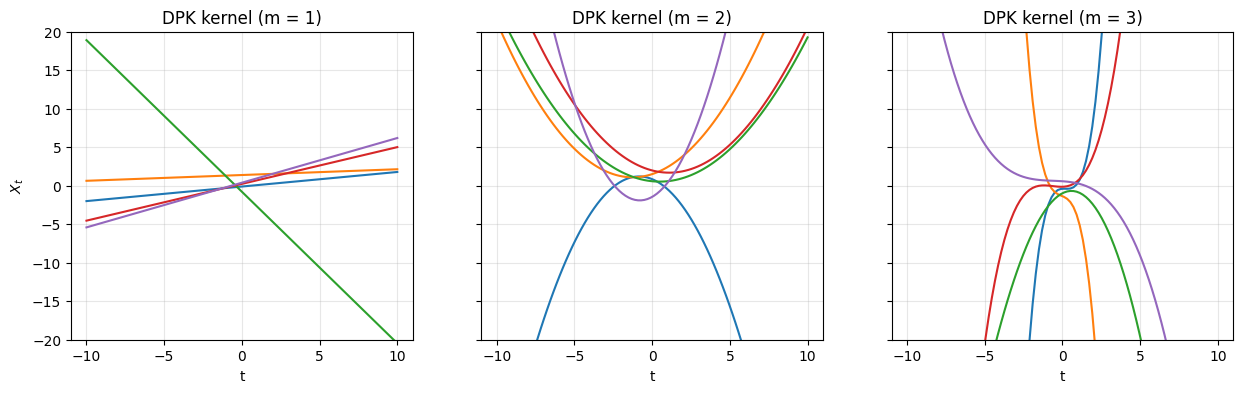

In [31]:
# COMPLETAR (PARA LA DIAPOSITIVA 89)
t = np.linspace(-10,10,100)
# Parámetros

grados = [1,2,3]
num_samples = 5

fig, ejes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for i, m in enumerate(grados):

    samples = simular_GP_DPKpoly(
        t,
        m=m,
        num_samples=num_samples
    )

    # Pintar trayectorias
    for j in range(num_samples):
        ejes[i].plot(t, samples[j])
    ejes[i].set_title(rf"DPK kernel (m = {m})")
    ejes[i].set_xlabel("t")
    ejes[i].grid(True, alpha=0.3)

ejes[0].set_ylabel(r"$X_t$")
ejes[0].set_ylim(-20, 20)


plt.show()